# Sto. HyMoLAP notebook

This notebook implements a stochastic hydrological model of the form

\[
dQ(t)=\left[-\frac{a}{b}Q(t)^{2a-1}+\frac{1}{b}\psi(q,t)\right]dt+\theta Q(t)\,dL(t)
\]

where:

- \(Q(t)\): discharge
- \(a, b\): structural parameters of the deterministic drift
- \(\psi(q,t)\): effective forcing
- \(\theta Q(t)\): multiplicative diffusion
- \(dL(t)\): stochastic increment, which can be:
  - **Gaussian**: \(dW(t)\)
  - **Lévy stable**: \(dL_\alpha(t)\)

The notebook is organized so you can:
1. simulate the model,
2. choose Gaussian or Lévy noise,
3. calibrate \(a\) and \(b\) from observed discharge,
4. optionally calibrate \(\theta\) too.

---

## Practical question: do you only need to calibrate `a` and `b`?

**Not necessarily.**

- If you want a **minimal deterministic structure**, then yes, the main structural parameters are usually **`a` and `b`**.
- But once the model is stochastic, the uncertainty term also matters:
  - **`theta`** controls the noise amplitude,
  - if you use Lévy noise, then **`alpha_levy`** (tail heaviness) and optionally **`beta_levy`** (skewness) also matter.

### Recommended strategy
Start simple:

- first calibrate **`a` and `b`**
- then test whether a fixed **`theta`** is enough
- only after that consider calibrating Lévy parameters

That is usually the safest workflow.

In [1]:
# Core imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Dict, Tuple, List
from scipy.stats import levy_stable
from scipy.optimize import differential_evolution

## Helper metrics

We define a few common objective functions for calibration.

In [2]:
def nse(obs: np.ndarray, sim: np.ndarray) -> float:
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    mask = np.isfinite(obs) & np.isfinite(sim)
    obs = obs[mask]
    sim = sim[mask]
    denom = np.sum((obs - np.mean(obs))**2)
    if denom == 0:
        return np.nan
    return 1.0 - np.sum((obs - sim)**2) / denom


def rmse(obs: np.ndarray, sim: np.ndarray) -> float:
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    mask = np.isfinite(obs) & np.isfinite(sim)
    obs = obs[mask]
    sim = sim[mask]
    return np.sqrt(np.mean((obs - sim)**2))


def pbias(obs: np.ndarray, sim: np.ndarray) -> float:
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    mask = np.isfinite(obs) & np.isfinite(sim)
    obs = obs[mask]
    sim = sim[mask]
    denom = np.sum(obs)
    if denom == 0:
        return np.nan
    return 100.0 * np.sum(sim - obs) / denom


def kge(obs: np.ndarray, sim: np.ndarray) -> float:
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    mask = np.isfinite(obs) & np.isfinite(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) < 2:
        return np.nan
    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim, ddof=1) / np.std(obs, ddof=1) if np.std(obs, ddof=1) > 0 else np.nan
    beta = np.mean(sim) / np.mean(obs) if np.mean(obs) != 0 else np.nan
    return 1.0 - np.sqrt((r - 1.0)**2 + (alpha - 1.0)**2 + (beta - 1.0)**2)

## Model design

We encapsulate the model in a class.

### Continuous-time SDE

\[
dQ(t)=\left[-\frac{a}{b}Q(t)^{2a-1}+\frac{1}{b}\psi(q,t)\right]dt+\theta Q(t)\,dL(t)
\]

### Euler–Maruyama discretization

For a time step \(\Delta t\),

\[
Q_{n+1}
=
Q_n
+
\left[
-\frac{a}{b}Q_n^{2a-1}
+\frac{1}{b}\psi_n
\right]\Delta t
+
\theta Q_n \Delta L_n
\]

with:

- **Gaussian noise**: \(\Delta L_n = \sqrt{\Delta t}\,\xi_n,\quad \xi_n \sim \mathcal{N}(0,1)\)
- **Lévy noise**: \(\Delta L_n \sim S_\alpha(\beta,\gamma \Delta t^{1/\alpha}, 0)\)

### Important note
This notebook includes a positivity safeguard so discharge does not become negative after stochastic updates.

In [3]:
@dataclass
class StoHyMoLAPConfig:
    a: float = 1.0
    b: float = 10.0
    theta: float = 0.05
    dt: float = 1.0
    noise_type: str = "gaussian"   # "gaussian" or "levy"
    alpha_levy: float = 1.7        # stability parameter for Levy noise
    beta_levy: float = 0.0         # skewness parameter
    levy_scale: float = 1.0
    q_min: float = 1e-8            # positivity floor
    random_seed: Optional[int] = 42


class StoHyMoLAP:
    """
    Stochastic HyMoLAP model.

    SDE:
        dQ = [-(a/b) Q^(2a-1) + (1/b) psi(t)] dt + theta * Q * dL

    where dL may be Gaussian or Levy-stable.
    """

    def __init__(self, config: StoHyMoLAPConfig):
        self.config = config
        self.rng = np.random.default_rng(config.random_seed)

    def forcing(self, psi: np.ndarray, t_idx: int) -> float:
        """
        Effective forcing term psi(q, t).
        In this implementation, it is provided directly as a time series.
        """
        return float(psi[t_idx])

    def drift(self, q: float, psi_t: float) -> float:
        a = self.config.a
        b = self.config.b
        q_safe = max(q, self.config.q_min)
        return -(a / b) * (q_safe ** (2 * a - 1)) + (1.0 / b) * psi_t

    def noise_increment(self) -> float:
        """
        Draw a stochastic increment dL for one time step dt.

        Gaussian:
            dL = sqrt(dt) * N(0,1)

        Levy:
            dL ~ levy_stable(alpha, beta, scale = levy_scale * dt^(1/alpha))
        """
        dt = self.config.dt

        if self.config.noise_type.lower() == "gaussian":
            return np.sqrt(dt) * self.rng.normal(0.0, 1.0)

        if self.config.noise_type.lower() == "levy":
            alpha = self.config.alpha_levy
            beta = self.config.beta_levy
            scale = self.config.levy_scale * (dt ** (1.0 / alpha))
            return levy_stable.rvs(
                alpha=alpha,
                beta=beta,
                loc=0.0,
                scale=scale,
                random_state=self.rng,
            )

        raise ValueError("noise_type must be 'gaussian' or 'levy'")

    def step(self, q: float, psi_t: float) -> float:
        """
        One Euler-Maruyama step.
        """
        dt = self.config.dt
        theta = self.config.theta

        drift_term = self.drift(q, psi_t) * dt
        diffusion_term = theta * q * self.noise_increment()

        q_next = q + drift_term + diffusion_term

        # positivity safeguard
        return max(q_next, self.config.q_min)

    def simulate(self, psi: np.ndarray, q0: float) -> np.ndarray:
        """
        Simulate one discharge trajectory.
        """
        psi = np.asarray(psi, dtype=float)
        q = np.empty(len(psi), dtype=float)
        q[0] = max(float(q0), self.config.q_min)

        for t in range(len(psi) - 1):
            psi_t = self.forcing(psi, t)
            q[t + 1] = self.step(q[t], psi_t)

        return q

    def simulate_ensemble(self, psi: np.ndarray, q0: float, n_members: int = 100) -> np.ndarray:
        """
        Simulate an ensemble of trajectories.
        Returns array of shape (n_members, n_time).
        """
        out = []
        for _ in range(n_members):
            out.append(self.simulate(psi=psi, q0=q0))
        return np.vstack(out)

## Synthetic example

Below we generate a simple forcing and simulate discharge, first with Gaussian noise and then with Lévy noise.

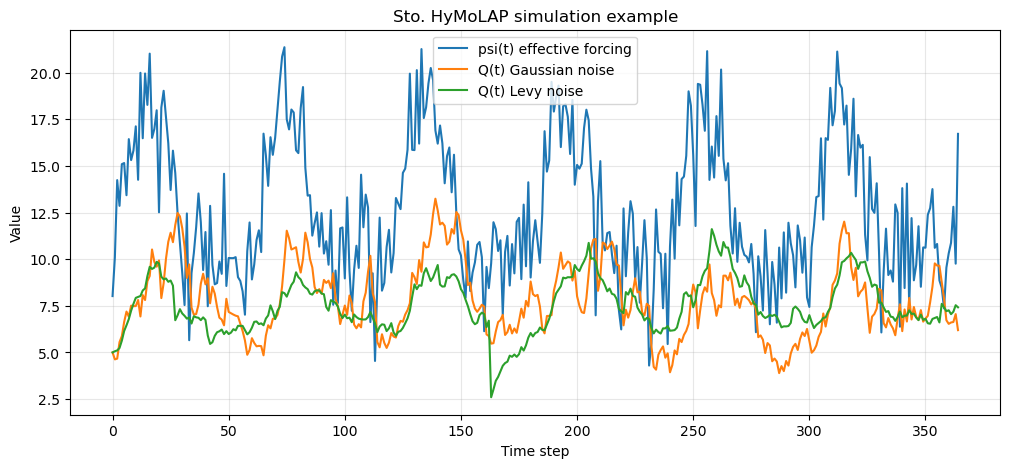

In [4]:
# Synthetic forcing example
n = 365
time = np.arange(n)

# Example effective forcing psi(t)
psi = 10 + 8*np.maximum(np.sin(2*np.pi*time/60), 0) + 2*np.random.default_rng(123).normal(size=n)
psi = np.maximum(psi, 0.0)

q0 = 5.0

# Gaussian version
cfg_gauss = StoHyMoLAPConfig(
    a=1.1,
    b=18.0,
    theta=0.08,
    dt=1.0,
    noise_type="gaussian",
    random_seed=123
)
model_gauss = StoHyMoLAP(cfg_gauss)
q_gauss = model_gauss.simulate(psi=psi, q0=q0)

# Levy version
cfg_levy = StoHyMoLAPConfig(
    a=1.1,
    b=18.0,
    theta=0.04,
    dt=1.0,
    noise_type="levy",
    alpha_levy=1.6,
    beta_levy=0.0,
    levy_scale=0.5,
    random_seed=123
)
model_levy = StoHyMoLAP(cfg_levy)
q_levy = model_levy.simulate(psi=psi, q0=q0)

plt.figure(figsize=(12, 5))
plt.plot(time, psi, label="psi(t) effective forcing", linewidth=1.5)
plt.plot(time, q_gauss, label="Q(t) Gaussian noise", linewidth=1.5)
plt.plot(time, q_levy, label="Q(t) Levy noise", linewidth=1.5)
plt.xlabel("Time step")
plt.ylabel("Value")
plt.title("Sto. HyMoLAP simulation example")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Ensemble interpretation

For a stochastic model, a single trajectory is not the whole story.  
The ensemble gives a practical approximation of the evolving probability distribution of discharge.

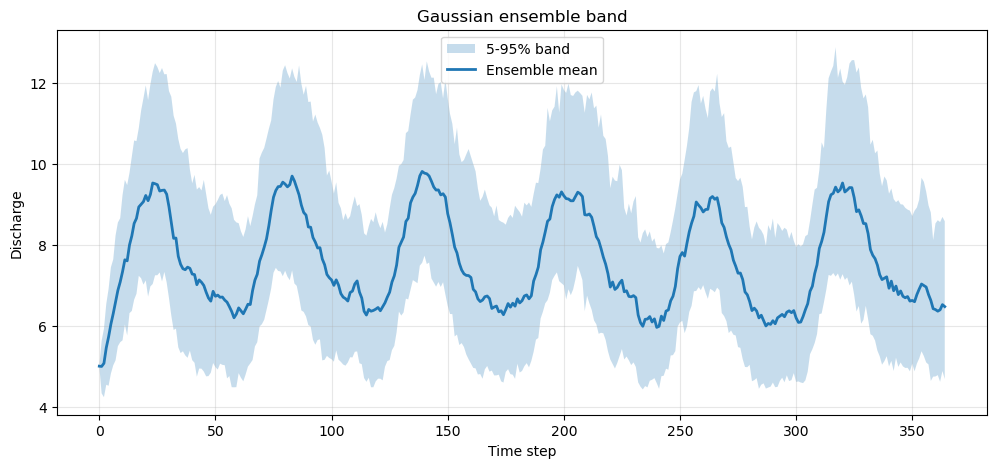

In [5]:
ens = model_gauss.simulate_ensemble(psi=psi, q0=q0, n_members=200)

q_mean = np.mean(ens, axis=0)
q_p05 = np.percentile(ens, 5, axis=0)
q_p95 = np.percentile(ens, 95, axis=0)

plt.figure(figsize=(12, 5))
plt.fill_between(time, q_p05, q_p95, alpha=0.25, label="5-95% band")
plt.plot(time, q_mean, label="Ensemble mean", linewidth=2)
plt.xlabel("Time step")
plt.ylabel("Discharge")
plt.title("Gaussian ensemble band")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Calibration

This section calibrates the model against an observed discharge series.

### Important modeling note
Because the model is stochastic, the objective function is itself noisy.  
A common practical workaround is to calibrate using:

- a fixed random seed, or
- the ensemble mean across several members.

Below I use the **ensemble mean**.

In [6]:
def simulate_mean_response(
    psi: np.ndarray,
    q0: float,
    params: Dict[str, float],
    base_config: StoHyMoLAPConfig,
    n_members: int = 30
) -> np.ndarray:
    """
    Simulate multiple stochastic trajectories and return their ensemble mean.
    """
    cfg = StoHyMoLAPConfig(
        a=params.get("a", base_config.a),
        b=params.get("b", base_config.b),
        theta=params.get("theta", base_config.theta),
        dt=base_config.dt,
        noise_type=base_config.noise_type,
        alpha_levy=base_config.alpha_levy,
        beta_levy=base_config.beta_levy,
        levy_scale=base_config.levy_scale,
        q_min=base_config.q_min,
        random_seed=base_config.random_seed,
    )
    model = StoHyMoLAP(cfg)
    ens = model.simulate_ensemble(psi=psi, q0=q0, n_members=n_members)
    return np.mean(ens, axis=0)


def objective_ab(
    x: np.ndarray,
    psi: np.ndarray,
    q_obs: np.ndarray,
    q0: float,
    base_config: StoHyMoLAPConfig,
    metric: str = "nse",
    n_members: int = 30
) -> float:
    """
    Objective function for calibrating a and b only.
    """
    a, b = x
    params = {"a": a, "b": b}
    q_sim = simulate_mean_response(
        psi=psi,
        q0=q0,
        params=params,
        base_config=base_config,
        n_members=n_members,
    )

    if metric.lower() == "nse":
        return -nse(q_obs, q_sim)  # maximize NSE = minimize negative NSE
    elif metric.lower() == "rmse":
        return rmse(q_obs, q_sim)
    elif metric.lower() == "kge":
        return -kge(q_obs, q_sim)
    else:
        raise ValueError("metric must be 'nse', 'rmse', or 'kge'")


def objective_abtheta(
    x: np.ndarray,
    psi: np.ndarray,
    q_obs: np.ndarray,
    q0: float,
    base_config: StoHyMoLAPConfig,
    metric: str = "nse",
    n_members: int = 30
) -> float:
    """
    Objective function for calibrating a, b, and theta.
    """
    a, b, theta = x
    params = {"a": a, "b": b, "theta": theta}
    q_sim = simulate_mean_response(
        psi=psi,
        q0=q0,
        params=params,
        base_config=base_config,
        n_members=n_members,
    )

    if metric.lower() == "nse":
        return -nse(q_obs, q_sim)
    elif metric.lower() == "rmse":
        return rmse(q_obs, q_sim)
    elif metric.lower() == "kge":
        return -kge(q_obs, q_sim)
    else:
        raise ValueError("metric must be 'nse', 'rmse', or 'kge'")

## Example calibration on synthetic observations

Here we create synthetic observations so the notebook runs end-to-end.  
Replace `q_obs` and `psi_obs` with your real forcing and observed discharge.

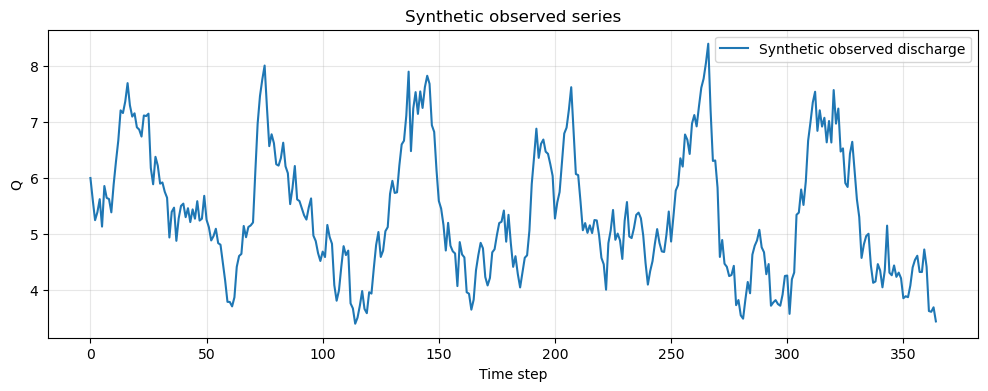

In [7]:
# Create synthetic "observed" discharge
true_cfg = StoHyMoLAPConfig(
    a=1.2,
    b=16.0,
    theta=0.06,
    dt=1.0,
    noise_type="gaussian",
    random_seed=99
)
true_model = StoHyMoLAP(true_cfg)

psi_obs = psi.copy()
q_obs = true_model.simulate(psi=psi_obs, q0=6.0)

plt.figure(figsize=(12, 4))
plt.plot(q_obs, label="Synthetic observed discharge")
plt.title("Synthetic observed series")
plt.xlabel("Time step")
plt.ylabel("Q")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Base config for calibration
base_cfg = StoHyMoLAPConfig(
    a=1.0,
    b=20.0,
    theta=0.05,
    dt=1.0,
    noise_type="gaussian",
    random_seed=123
)

# Calibrate a and b only
bounds_ab = [
    (0.6, 2.0),   # a
    (1.0, 40.0),  # b
]

result_ab = differential_evolution(
    objective_ab,
    bounds=bounds_ab,
    args=(psi_obs, q_obs, q_obs[0], base_cfg, "nse", 40),
    seed=123,
    maxiter=20,
    polish=True,
)

best_a, best_b = result_ab.x
best_score = -result_ab.fun

print("Best a:", best_a)
print("Best b:", best_b)
print("Best NSE:", best_score)

Best a: 1.1973658025743086
Best b: 14.636355086746326
Best NSE: 0.7532245865807529


Calibration metrics (a, b only)
NSE  : 0.7577044543772548
KGE  : 0.7545653190413809
RMSE : 0.5549362563210386
PBIAS: 0.5081881043863621


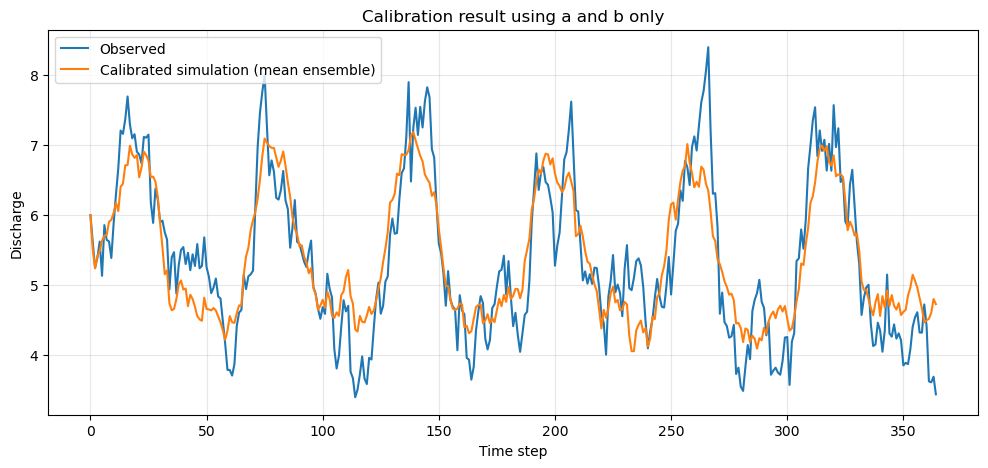

In [9]:
# Simulate with calibrated a and b
q_cal_ab = simulate_mean_response(
    psi=psi_obs,
    q0=q_obs[0],
    params={"a": best_a, "b": best_b},
    base_config=base_cfg,
    n_members=100
)

print("Calibration metrics (a, b only)")
print("NSE  :", nse(q_obs, q_cal_ab))
print("KGE  :", kge(q_obs, q_cal_ab))
print("RMSE :", rmse(q_obs, q_cal_ab))
print("PBIAS:", pbias(q_obs, q_cal_ab))

plt.figure(figsize=(12, 5))
plt.plot(q_obs, label="Observed", linewidth=1.5)
plt.plot(q_cal_ab, label="Calibrated simulation (mean ensemble)", linewidth=1.5)
plt.title("Calibration result using a and b only")
plt.xlabel("Time step")
plt.ylabel("Discharge")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Optional: calibrate `theta` too

If you want the stochastic amplitude to be data-informed, calibrating `theta` can be worthwhile.

Best a     : 1.1975563158739704
Best b     : 15.669358238292764
Best theta : 0.001
Best NSE   : 0.7636280581405189

Calibration metrics (a, b, theta)
NSE  : 0.7636805465530621
KGE  : 0.749242079590605
RMSE : 0.5480499238522244
PBIAS: 0.5216341197859089


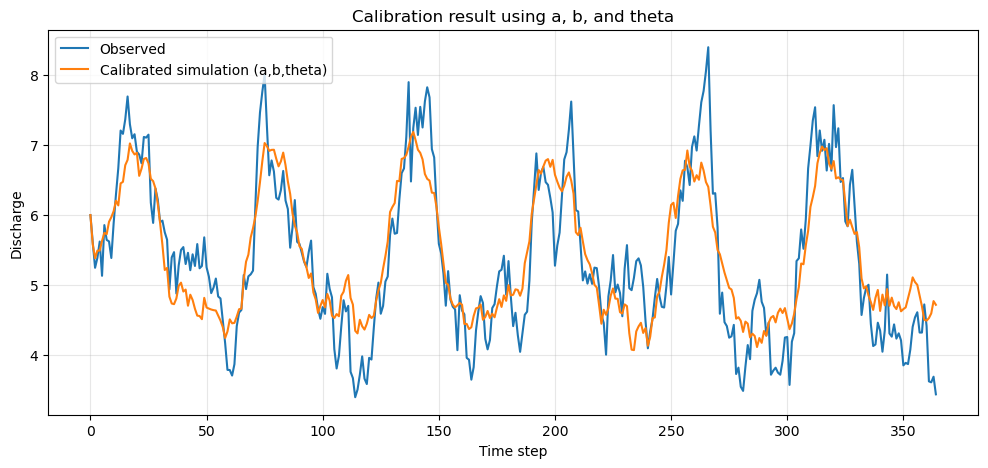

In [10]:
bounds_abtheta = [
    (0.6, 2.0),   # a
    (1.0, 40.0),  # b
    (0.001, 0.3), # theta
]

result_abtheta = differential_evolution(
    objective_abtheta,
    bounds=bounds_abtheta,
    args=(psi_obs, q_obs, q_obs[0], base_cfg, "nse", 40),
    seed=123,
    maxiter=20,
    polish=True,
)

best_a2, best_b2, best_theta2 = result_abtheta.x

q_cal_abtheta = simulate_mean_response(
    psi=psi_obs,
    q0=q_obs[0],
    params={"a": best_a2, "b": best_b2, "theta": best_theta2},
    base_config=base_cfg,
    n_members=100
)

print("Best a     :", best_a2)
print("Best b     :", best_b2)
print("Best theta :", best_theta2)
print("Best NSE   :", -result_abtheta.fun)

print("\nCalibration metrics (a, b, theta)")
print("NSE  :", nse(q_obs, q_cal_abtheta))
print("KGE  :", kge(q_obs, q_cal_abtheta))
print("RMSE :", rmse(q_obs, q_cal_abtheta))
print("PBIAS:", pbias(q_obs, q_cal_abtheta))

plt.figure(figsize=(12, 5))
plt.plot(q_obs, label="Observed", linewidth=1.5)
plt.plot(q_cal_abtheta, label="Calibrated simulation (a,b,theta)", linewidth=1.5)
plt.title("Calibration result using a, b, and theta")
plt.xlabel("Time step")
plt.ylabel("Discharge")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## How to use your real data

Replace the synthetic section with something like:

```python
df = pd.read_csv("your_data.csv")
psi_obs = df["psi"].to_numpy()
q_obs = df["Qobs"].to_numpy()
q0 = q_obs[0]
```

Then run the calibration cells.

### Recommendation for real applications
A practical order is:

1. define `psi(q,t)` carefully,
2. calibrate `a` and `b`,
3. evaluate residual structure,
4. calibrate `theta`,
5. only then move to Lévy noise if extremes and heavy tails matter.

If you directly calibrate everything at once, identifiability may become weak.

## Final interpretation

### Minimal calibration
If your goal is just to identify the deterministic structure, then yes:

- calibrate **`a`**
- calibrate **`b`**

### More complete stochastic calibration
If your goal is to represent uncertainty realistically, then also consider:

- **`theta`** for noise magnitude
- **`alpha_levy`** for tail heaviness
- **`beta_levy`** for asymmetry, if needed

In most first implementations, calibrating only `a` and `b` is a good start.

In [11]:
df = pd.read_csv("../data.csv",encoding='utf-8', sep = ';')
df['psi'] = df['Precipitation'] - df['PET']

In [12]:
psi_obs = df["psi"].to_numpy()
q_obs = df["Qobs"].to_numpy()
q0 = q_obs[0]

In [ ]:
base_cfg = StoHyMoLAPConfig(
    a=1.0,
    b=20.0,
    theta=0.05,
    dt=1.0,
    noise_type="levy",
    random_seed=123
)

bounds_abtheta = [
    (0.6, 2.0),   # a
    (1.0, 40.0),  # b
    (0.001, 0.3), # theta
]

result_abtheta = differential_evolution(
    objective_abtheta,
    bounds=bounds_abtheta,
    args=(psi_obs, q_obs, q_obs[0], base_cfg, "nse", 40),
    seed=123,
    maxiter=20,
    polish=True,
    workers=-1,          # <--- USA TODOS LOS NÚCLEOS DE TU CPU
    updating='deferred'  # <--- NECESARIO PARA PARALELISMO
)

best_a2, best_b2, best_theta2 = result_abtheta.x

q_cal_abtheta = simulate_mean_response(
    psi=psi_obs,
    q0=q_obs[0],
    params={"a": best_a2, "b": best_b2, "theta": best_theta2},
    base_config=base_cfg,
    n_members=100
)

print("Best a     :", best_a2)
print("Best b     :", best_b2)
print("Best theta :", best_theta2)
print("Best NSE   :", -result_abtheta.fun)

print("\nCalibration metrics (a, b, theta)")
print("NSE  :", nse(q_obs, q_cal_abtheta))
print("KGE  :", kge(q_obs, q_cal_abtheta))
print("RMSE :", rmse(q_obs, q_cal_abtheta))
print("PBIAS:", pbias(q_obs, q_cal_abtheta))

plt.figure(figsize=(12, 5))
plt.plot(q_obs, label="Observed", linewidth=1.5)
plt.plot(q_cal_abtheta, label="Calibrated simulation (a,b,theta)", linewidth=1.5)
plt.title("Calibration result using a, b, and theta")
plt.xlabel("Time step")
plt.ylabel("Discharge")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Process ForkServerPoolWorker-20:
Traceback (most recent call last):
  File "/home/jose/miniconda3/envs/tf/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/jose/miniconda3/envs/tf/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/jose/miniconda3/envs/tf/lib/python3.11/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/home/jose/miniconda3/envs/tf/lib/python3.11/multiprocessing/queues.py", line 367, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'objective_abtheta' on <module '__main__' (built-in)>
Process ForkServerPoolWorker-9:
Traceback (most recent call last):
  File "/home/jose/miniconda3/envs/tf/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/jose/miniconda3/envs/tf/lib/python3.11/multiprocessing/process.py",